# MSCS 634 – Lab 6  
## Association Rule Mining with Apriori and FP-Growth

Name: Vamsi Krishna Gajulapalli
Course: MSCS 634  
Lab: Lab 6  

# Step 1: Data preparation and cleaning

In [1]:
import pandas as pd

file_path = r"C:\Users\Dell\Downloads\Online Retail.xlsx"
df = pd.read_excel(file_path)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [2]:
# Importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Online Retail dataset
file_path = r"C:\Users\Dell\Downloads\Online Retail.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully.\n")

# Viewing the first few rows
print("First 5 rows of dataset:")
print(df.head())

# Checking dataset structure
print("\nDataset information:")
print(df.info())

# Removing missing values in important columns
df = df.dropna(subset=["InvoiceNo", "Description"])

# Removing cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keeping only positive quantities
df = df[df["Quantity"] > 0]

# Converting item names to string format
df["Description"] = df["Description"].astype(str)

print("\nCleaned dataset shape:", df.shape)

# Creating basket format for association rule mining
basket = df.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)

# Converting values to 1 and 0
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket format created successfully.")
print("Basket shape:", basket.shape)

# Finding top 10 most frequent items
top_items = basket.sum().sort_values(ascending=False).head(10)

# Visualizing top 10 most frequent items
plt.figure(figsize=(10, 5))
sns.barplot(x=top_items.values, y=top_items.index)

plt.title("Top 10 Most Frequent Items")
plt.xlabel("Frequency")
plt.ylabel("Items")

plt.show()

# Creating item co-occurrence heatmap using top 10 items
top_10_items = top_items.index
co_occurrence = basket[top_10_items].T.dot(basket[top_10_items])

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, cmap="YlGnBu", annot=True, fmt="d")

plt.title("Item Co-occurrence Heatmap")
plt.show()

Dataset loaded successfully.

First 5 rows of dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column  

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [5]:
# Convert basket values to binary boolean format
basket = basket.apply(lambda col: col > 0)

print(basket.head())
print(basket.dtypes.head())

Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                False                           False   
536366                                False                           False   
536367                                False                           False   
536368                                False                           False   
536369                                False                           False   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                    False                         False   
536366                    False                         False   
536367                    False                         False   
536368                    False                         False   
536369                    False                         

# Step 2: Apriori

Apriori frequent itemsets created successfully.

      support                                         itemsets
273  0.112237  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
102  0.103894             frozenset({JUMBO BAG RED RETROSPOT})
197  0.098778            frozenset({REGENCY CAKESTAND 3 TIER})
157  0.083731                       frozenset({PARTY BUNTING})
127  0.077672             frozenset({LUNCH BAG RED RETROSPOT})
15   0.072259       frozenset({ASSORTED COLOUR BIRD ORNAMENT})
218  0.068782   frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
149  0.065554     frozenset({PACK OF 72 RETROSPOT CAKE CASES})
120  0.063220             frozenset({LUNCH BAG  BLACK SKULL.})
139  0.062028     frozenset({NATURAL SLATE HEART CHALKBOARD })


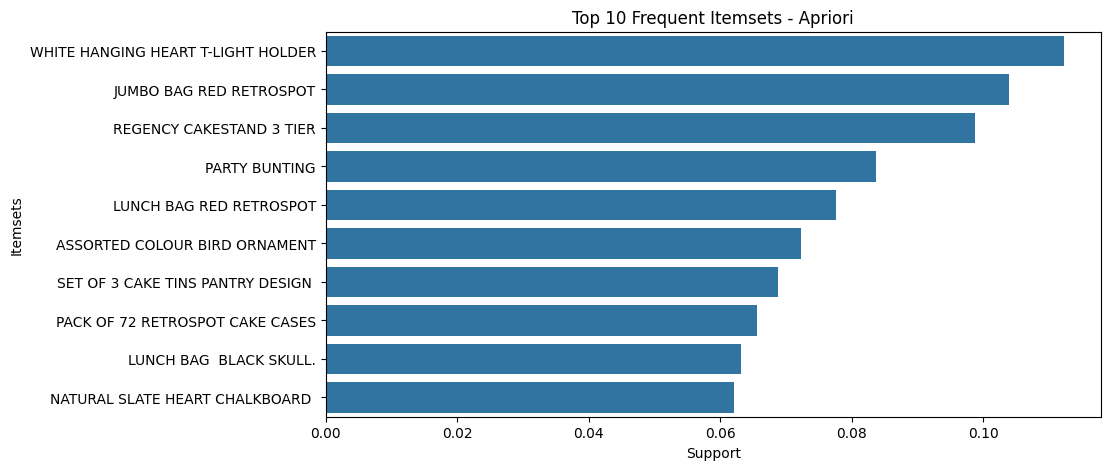

In [9]:
# Importing Apriori
from mlxtend.frequent_patterns import apriori

# Converting basket to boolean format
basket = basket > 0

# Generating frequent itemsets using Apriori
frequent_itemsets_apriori = apriori(basket, min_support=0.02, use_colnames=True)

# Sorting itemsets by support
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(by="support", ascending=False)

print("Apriori frequent itemsets created successfully.\n")

# Displaying top 10 itemsets
print(frequent_itemsets_apriori.head(10))

# Creating readable itemset names
frequent_itemsets_apriori["itemset_names"] = frequent_itemsets_apriori["itemsets"].apply(lambda x: ", ".join(list(x)))

# Plotting top 10 itemsets
top_apriori = frequent_itemsets_apriori.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_apriori["support"], y=top_apriori["itemset_names"])

plt.title("Top 10 Frequent Itemsets - Apriori")
plt.xlabel("Support")
plt.ylabel("Itemsets")

plt.show()

# Step 3: FP-Growth

FP-Growth frequent itemsets created successfully.

      support                                         itemsets
0    0.112237  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
66   0.103894             frozenset({JUMBO BAG RED RETROSPOT})
162  0.098778            frozenset({REGENCY CAKESTAND 3 TIER})
232  0.083731                       frozenset({PARTY BUNTING})
29   0.077672             frozenset({LUNCH BAG RED RETROSPOT})
4    0.072259       frozenset({ASSORTED COLOUR BIRD ORNAMENT})
243  0.068782   frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
30   0.065554     frozenset({PACK OF 72 RETROSPOT CAKE CASES})
107  0.063220             frozenset({LUNCH BAG  BLACK SKULL.})
56   0.062028     frozenset({NATURAL SLATE HEART CHALKBOARD })


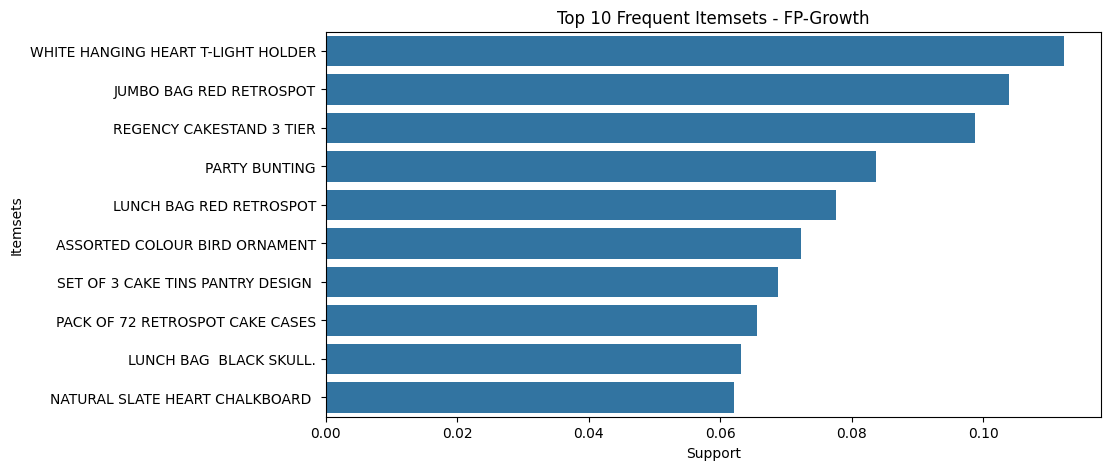

In [10]:
# Importing FP-Growth
from mlxtend.frequent_patterns import fpgrowth

# Generating frequent itemsets using FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(basket, min_support=0.02, use_colnames=True)

# Sorting itemsets by support
frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth.sort_values(by="support", ascending=False)

print("FP-Growth frequent itemsets created successfully.\n")

# Displaying top 10 itemsets
print(frequent_itemsets_fpgrowth.head(10))

# Creating readable itemset names
frequent_itemsets_fpgrowth["itemset_names"] = frequent_itemsets_fpgrowth["itemsets"].apply(lambda x: ", ".join(list(x)))

# Plotting top 10 itemsets
top_fpgrowth = frequent_itemsets_fpgrowth.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_fpgrowth["support"], y=top_fpgrowth["itemset_names"])

plt.title("Top 10 Frequent Itemsets - FP-Growth")
plt.xlabel("Support")
plt.ylabel("Itemsets")

plt.show()

# Step 4: Association Rules

In [11]:
# Importing association rules
from mlxtend.frequent_patterns import association_rules

# Generating rules from Apriori
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.3)

# Sorting rules by lift
rules_apriori = rules_apriori.sort_values(by="lift", ascending=False)

print("Top Association Rules (Apriori):\n")
print(rules_apriori[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

Top Association Rules (Apriori):

                                          antecedents  \
38        frozenset({PINK REGENCY TEACUP AND SAUCER})   
33  frozenset({ROSES REGENCY TEACUP AND SAUCER , G...   
34  frozenset({ROSES REGENCY TEACUP AND SAUCER , P...   
37       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
13        frozenset({PINK REGENCY TEACUP AND SAUCER})   
12       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
35  frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...   
36      frozenset({ROSES REGENCY TEACUP AND SAUCER })   
29     frozenset({GARDENERS KNEELING PAD KEEP CALM })   
30    frozenset({GARDENERS KNEELING PAD CUP OF TEA })   

                                          consequents   support  confidence  \
38  frozenset({ROSES REGENCY TEACUP AND SAUCER , G...  0.026917    0.707572   
33        frozenset({PINK REGENCY TEACUP AND SAUCER})  0.026917    0.705729   
34       frozenset({GREEN REGENCY TEACUP AND SAUCER})  0.026917    0.904841   
37  frozenset({ROSES R

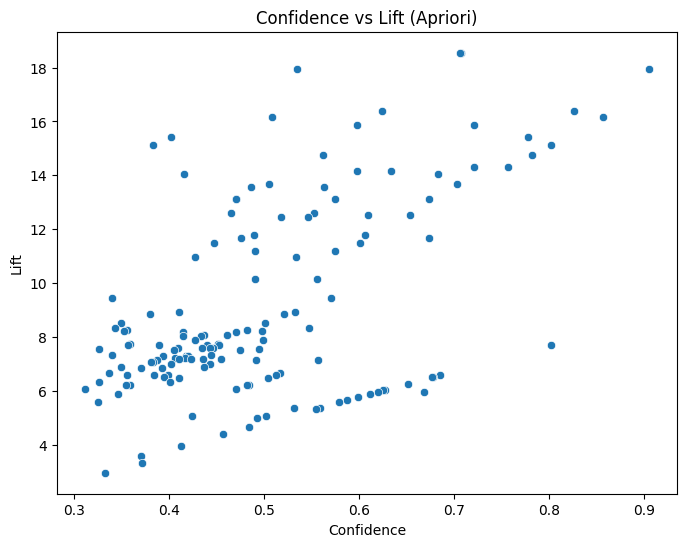

In [12]:
# Plotting confidence vs lift
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rules_apriori, x="confidence", y="lift")

plt.title("Confidence vs Lift (Apriori)")
plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.show()

## FP-Growth Rules

In [13]:
# Generating rules from FP-Growth
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.3)

# Sorting rules by lift
rules_fpgrowth = rules_fpgrowth.sort_values(by="lift", ascending=False)

print("Top Association Rules (FP-Growth):\n")
print(rules_fpgrowth[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

Top Association Rules (FP-Growth):

                                          antecedents  \
38        frozenset({PINK REGENCY TEACUP AND SAUCER})   
33  frozenset({ROSES REGENCY TEACUP AND SAUCER , G...   
34  frozenset({ROSES REGENCY TEACUP AND SAUCER , P...   
37       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
13        frozenset({PINK REGENCY TEACUP AND SAUCER})   
12       frozenset({GREEN REGENCY TEACUP AND SAUCER})   
35  frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...   
36      frozenset({ROSES REGENCY TEACUP AND SAUCER })   
28     frozenset({GARDENERS KNEELING PAD KEEP CALM })   
29    frozenset({GARDENERS KNEELING PAD CUP OF TEA })   

                                          consequents   support  confidence  \
38  frozenset({ROSES REGENCY TEACUP AND SAUCER , G...  0.026917    0.707572   
33        frozenset({PINK REGENCY TEACUP AND SAUCER})  0.026917    0.705729   
34       frozenset({GREEN REGENCY TEACUP AND SAUCER})  0.026917    0.904841   
37  frozenset({ROSES

## Step 5: Analysis and Insights
Both Apriori and FP-Growth produced very similar frequent itemsets on the 
Online Retail dataset. The most common items included WHITE HANGING HEART 
T-LIGHT HOLDER, JUMBO BAG RED RETROSPOT, and REGENCY CAKESTAND 3 TIER. 
These items appeared frequently across transactions, indicating strong 
purchasing trends.

The FP-Growth algorithm was more efficient compared to Apriori. Apriori 
requires generating many candidate itemsets and scanning the dataset 
multiple times, which increases computational cost. In contrast, FP-Growth 
uses a tree-based structure that avoids candidate generation, making it 
faster and more scalable for large datasets.

The association rules generated from both algorithms revealed strong 
relationships between products, especially among decorative and gift items. 
Several rules showed high confidence and high lift values, indicating that 
certain items are often purchased together. For example, tea cup and saucer 
sets frequently appeared together in transactions.

Overall, FP-Growth performed better in terms of efficiency, while both 
algorithms were equally effective in identifying meaningful patterns. 
A key challenge in this lab was converting the transactional data into the 
correct basket format, as the algorithms require boolean values rather than 
raw quantities.